In [1]:
import torch as t
from utils import DataManager
import random
import matplotlib.pyplot as plt
import random
from probes import LRProbe, MMProbe, CCSProbe
import configparser
import json

In [2]:
seed = random.randint(0, 10000)

In [3]:
# hyperparameters
model = 'llama-3.1-8B-Instruct'
split = 0.8
device = 'cuda:0' if t.cuda.is_available() else 'cpu'

config = configparser.ConfigParser()
config.read('config.ini')
layer = eval(config[model]['probe_layer'])
noperiod = eval(config[model]['noperiod'])

In [4]:
train_medlies  = [
    ['cities'],
    ['cities', 'neg_cities'],
    ['larger_than'],
    ['larger_than', 'smaller_than'],
    # ['likely']
]

val_datasets = [
    'cities',
    'neg_cities',
    'larger_than',
    'smaller_than',
    'sp_en_trans',
    'neg_sp_en_trans',
    # 'cities_cities_conj',
    # 'cities_cities_disj',
    # 'companies_true_false',
    # 'common_claim_true_false',
    # 'counterfact_true_false'    
]

def to_str(l):
    return '+'.join(l)

In [5]:
def generate_dm(medley, model: str, layer, split, seed, noperiod, device):
    dm = DataManager()
    for dataset in medley:
        dm.add_dataset(dataset, model, layer, split=split, seed=seed, noperiod=noperiod, center=True, device=device)
    for dataset in val_datasets:
        if dataset not in medley:
            dm.add_dataset(dataset, model, layer, split=None, noperiod=noperiod, center=True, device=device)
    return dm

def train_probe(dm, ProbeClass):
    # train probe
    train_acts, train_labels = dm.get('train')
    probe = ProbeClass.from_data(train_acts, train_labels, device=device)
    direction = probe.direction
    return probe, direction

def test_probe(val_datasets, medley, dm, accs, ProbeClass, probe):
    val_preds = []
    for val_dataset in val_datasets:
        if val_dataset in medley:
            acts, labels = dm.data['val'][val_dataset]
            accs[str(ProbeClass)][to_str(medley)][val_dataset] = (
                probe.pred(acts, iid=True) == labels
            ).float().mean().item()
            val_preds.append((probe.pred(acts, iid=True) == labels).float())
        else:
            acts, labels = dm.data[val_dataset]
            accs[str(ProbeClass)][to_str(medley)][val_dataset] = (
                probe.pred(acts, iid=False) == labels
            ).float().mean().item()
            val_preds.append((probe.pred(acts, iid=False) == labels).float())
    accs[str(ProbeClass)][to_str(medley)]['overall_test_acc'] = t.cat(val_preds, dim=0).mean().item()

In [7]:
for model in ['llama-3.1-8B', 'llama-3.1-8B-Instruct']:
    ProbeClasses = [
        LRProbe,
        MMProbe,
        ]

    accs = {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses}
    for layer in range(32):
        for ProbeClass in ProbeClasses:
            for medley in train_medlies:

                # set up data
                dm = generate_dm(medley, model, layer, split, seed, noperiod, device)

                probe_probe, probe_direction = train_probe(dm, ProbeClass)

                test_probe(val_datasets, medley, dm, accs, ProbeClass, probe_probe)


        lr_mm_accs = accs.copy()

        with open('experimental_outputs/generalization_results_per_layer.json', 'r') as f:
            outs = json.load(f)

        for ProbeClass in ProbeClasses:
            out = accs[str(ProbeClass)]
            out['model'] = model
            out['probe'] = ProbeClass.__str__()
            out['layer'] = layer
            out['noperiod'] = noperiod
            outs.append(out)

        with open('experimental_outputs/generalization_results_per_layer.json', 'w') as f:
            json.dump(outs, f, indent=2)

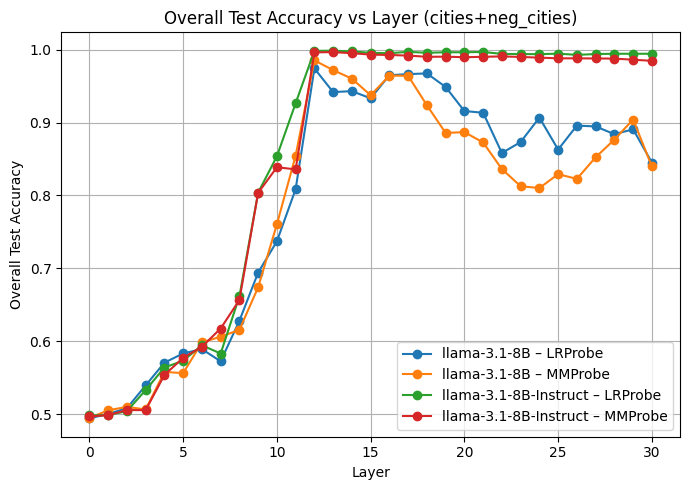

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --------------------
# CONFIG
# --------------------
json_path = "experimental_outputs/generalization_results_per_layer.json"

train_dataset = "cities+neg_cities"

models_to_plot = [
    "llama-3.1-8B",
    "llama-3.1-8B-Instruct",
]

probes_to_plot = [
    "MMProbe",
    "LRProbe"
]

# --------------------
# LOAD JSON
# --------------------
with open(json_path, "r") as f:
    data = json.load(f)

# --------------------
# EXTRACT DATA
# --------------------
rows = []

for entry in data:
    model = entry.get("model")
    probe = entry.get("probe")
    layer = entry.get("layer")

    if layer > 30:
        continue
    # filter by model
    if model not in models_to_plot:
        continue

    # filter by probe
    if probe not in probes_to_plot:
        continue

    # filter by dataset
    if train_dataset not in entry:
        continue

    acc = entry[train_dataset].get("overall_test_acc")
    if acc is None:
        continue

    rows.append({
        "model": model,
        "probe": probe,
        "layer": layer,
        "overall_test_acc": acc,
    })

df = pd.DataFrame(rows)

# --------------------
# PLOT
# --------------------
plt.figure(figsize=(7, 5))

for (model, probe), df_sub in df.groupby(["model", "probe"]):
    df_sub = df_sub.sort_values("layer")
    plt.plot(
        df_sub["layer"],
        df_sub["overall_test_acc"],
        marker="o",
        label=f"{model} – {probe}",
    )

plt.xlabel("Layer")
plt.ylabel("Overall Test Accuracy")
plt.title(f"Overall Test Accuracy vs Layer ({train_dataset})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()